# Kalman Filter Assignment — Complete Solutions

**Topics covered:** Analytical derivations, 1-D scalar filter, 2-D position estimation with GPS simulation.


# Q1. Analytical Derivation

## Part 1 — Distribution of $x_k^-$

**Given:**
$$x_{k-1}^+ \sim \mathscr{N}(m_{k-1}, P_{k-1}), \qquad w_{k-1} \sim \mathscr{N}(0, \Sigma_p), \quad \text{independent}$$

**Prediction step:**
$$x_k^- = A_{k-1}\,x_{k-1}^+ + G_{k-1}\,w_{k-1}$$

Since $x_k^-$ is an affine transformation of jointly Gaussian random variables, it is Gaussian.

**Mean:**
$$\mathbb{E}[x_k^-] = A_{k-1}\,\mathbb{E}[x_{k-1}^+] + G_{k-1}\,\mathbb{E}[w_{k-1}] = A_{k-1}\,m_{k-1} + 0 = m_k^-$$

**Covariance** (using independence of $x_{k-1}^+$ and $w_{k-1}$):
$$\mathrm{Var}(x_k^-) = A_{k-1}\,\mathrm{Var}(x_{k-1}^+)\,A_{k-1}^T + G_{k-1}\,\mathrm{Var}(w_{k-1})\,G_{k-1}^T$$
$$= A_{k-1}\,P_{k-1}\,A_{k-1}^T + G_{k-1}\,\Sigma_p\,G_{k-1}^T = P_k^-$$

Therefore:
$$\boxed{x_k^- \sim \mathscr{N}(m_k^-,\; P_k^-), \qquad m_k^- = A_{k-1}m_{k-1}, \quad P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T}$$


## Part 2 — Distribution of $y_k^-$

**Measurement model:**
$$y_k^- = H_k\,x_k^- + z_k, \qquad z_k \sim \mathscr{N}(0,\Sigma_m), \quad \text{independent of } x_k^-$$

Again an affine transformation of Gaussians:

**Mean:**
$$\mathbb{E}[y_k^-] = H_k\,\mathbb{E}[x_k^-] + 0 = H_k\,m_k^-$$

**Covariance:**
$$\mathrm{Var}(y_k^-) = H_k\,P_k^-\,H_k^T + \Sigma_m$$

Therefore:
$$\boxed{y_k^- \sim \mathscr{N}\!\left(H_k\,m_k^-,\; H_k\,P_k^-\,H_k^T + \Sigma_m\right)}$$


## Part 3 — Joint distribution of $(x_k^-, y_k^-)$

Define the joint vector $u = \begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix}$. It is Gaussian (linear transformation of Gaussians).

**Means** follow directly from Parts 1 and 2.

**Cross-covariance** (key step):
$$\mathrm{Cov}(x_k^-, y_k^-) = \mathrm{Cov}(x_k^-,\; H_k x_k^- + z_k) = \mathrm{Cov}(x_k^-,\;H_k x_k^-) + \underbrace{\mathrm{Cov}(x_k^-, z_k)}_{=0}$$
$$= \mathrm{Var}(x_k^-)\,H_k^T = P_k^-\,H_k^T$$

Assembling:
$$\boxed{\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathscr{N}\!\left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},\; \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)}$$


## Part 4 — Posterior $x_k^+ = (x_k^- \mid y_k^- = y_k^\mathrm{obs})$

Use the **Gaussian conditioning formula**: for joint Gaussian
$$\begin{bmatrix} u \\ v \end{bmatrix} \sim \mathscr{N}\!\left(\begin{bmatrix}\mu_u\\\mu_v\end{bmatrix}, \begin{bmatrix}\Sigma_{uu} & \Sigma_{uv}\\\Sigma_{vu} & \Sigma_{vv}\end{bmatrix}\right)$$
the conditional is $u \mid v = v_0 \sim \mathscr{N}(\mu_u + \Sigma_{uv}\Sigma_{vv}^{-1}(v_0-\mu_v),\; \Sigma_{uu} - \Sigma_{uv}\Sigma_{vv}^{-1}\Sigma_{vu})$.

Applying with $u = x_k^-$, $v = y_k^-$, $v_0 = y_k^\mathrm{obs}$:

$$\Sigma_{uv} = P_k^- H_k^T, \quad \Sigma_{vv} = H_k P_k^- H_k^T + \Sigma_m, \quad \Sigma_{vu} = H_k P_k^-$$

**Define the Kalman gain:**
$$K_k \triangleq P_k^- H_k^T \left(H_k P_k^- H_k^T + \Sigma_m\right)^{-1} = \Sigma_{uv}\,\Sigma_{vv}^{-1}$$

**Updated mean:**
$$m_k = m_k^- + K_k(y_k^\mathrm{obs} - H_k m_k^-)$$

**Updated covariance:**
$$P_k = P_k^- - P_k^- H_k^T \left(H_k P_k^- H_k^T + \Sigma_m\right)^{-1} H_k P_k^- = P_k^- - K_k H_k P_k^- = (I - K_k H_k)P_k^-$$

Therefore:
$$\boxed{x_k^+ \sim \mathscr{N}(m_k, P_k), \quad m_k = m_k^- + K_k(y_k^\mathrm{obs} - H_k m_k^-), \quad P_k = (I - K_k H_k)P_k^-}$$


## Part 5 — Conditional mean and variance

From Part 4 (these are simply the parameters of the posterior):

$$\mathbb{E}[x_k^- \mid y_k^- = y_k^\mathrm{obs}] = m_k = m_k^- + K_k(y_k^\mathrm{obs} - H_k m_k^-)$$

$$\mathrm{Var}(x_k^- \mid y_k^- = y_k^\mathrm{obs}) = P_k = (I - K_k H_k)P_k^-$$

These are the *updated* (posterior) mean and covariance produced by the Kalman update step. The posterior variance $P_k \preceq P_k^-$ (positive semi-definite ordering), confirming that the observation always reduces uncertainty.


# Q2. 1-D Scalar Example

## Parts 1 & 2 — Scalar Kalman equations

The scalar model is:
$$x_k^- = a\,x_{k-1}^+ + w_{k-1},\quad w_{k-1}\sim\mathscr{N}(0,q)$$
$$y_k^- = h\,x_k^- + z_k,\quad z_k\sim\mathscr{N}(0,r)$$

**Part 1 — Prediction** (direct application of Q1 Part 1 with $A=a$, $G=1$, $\Sigma_p=q$):
$$\boxed{m_k^- = a\,m_{k-1}, \qquad P_k^- = a^2 P_{k-1} + q}$$

**Part 2 — Update.** Define the innovation variance:
$$S_k \triangleq h^2 P_k^- + r \quad (\text{scalar version of } H_k P_k^- H_k^T + \Sigma_m)$$

The Kalman gain becomes the scalar:
$$K_k = \frac{P_k^-\,h}{S_k} = \frac{P_k^-\,h}{h^2 P_k^- + r}$$

Substituting into the update equations:
$$\boxed{m_k = m_k^- + \frac{P_k^-\,h}{S_k}(y_k^\mathrm{obs} - h\,m_k^-), \qquad P_k = \left(1 - \frac{P_k^-\,h^2}{S_k}\right)P_k^-}$$

## Part 3 — Predictive measurement distribution

Before seeing $y_k$, the predicted measurement is:
$$y_k^- = h\,x_k^- + z_k$$

Since $x_k^- \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0,r)$ independently:
$$\boxed{p(y_k^- \mid Y_{k-1}) = \mathscr{N}(h\,m_k^-,\; h^2 P_k^- + r)}$$

## Part 4 — Posterior-predictive measurement distribution

After the update, $x_k^+ \mid Y_k \sim \mathscr{N}(m_k, P_k)$. The one-step-ahead measurement prediction given $Y_k$ is:
$$y_k^- \mid Y_k = h\,x_k^+ + z_k$$
$$\boxed{p(y_k^- \mid Y_k) = \mathscr{N}(h\,m_k,\; h^2 P_k + r)}$$


## Part 5 — Animation: prior vs posterior distributions over time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm
from IPython.display import HTML

# ── Model parameters ──────────────────────────────────────────────────
a = 0.95      # state transition (slightly damped random walk)
q = 1.0       # process noise variance
h = 1.0       # measurement sensitivity
r = 2.0       # measurement noise variance

# ── Prior ─────────────────────────────────────────────────────────────
m0, P0 = 0.0, 5.0
np.random.seed(42)

T = 30        # time steps
# Simulate true state and noisy observations
x_true = np.zeros(T + 1)
y_obs  = np.zeros(T)
x_true[0] = np.random.randn() * np.sqrt(P0)
for k in range(T):
    x_true[k + 1] = a * x_true[k] + np.sqrt(q) * np.random.randn()
    y_obs[k]       = h * x_true[k + 1] + np.sqrt(r) * np.random.randn()

# ── Kalman filter pass ─────────────────────────────────────────────────
m_pred = np.zeros(T);  P_pred = np.zeros(T)
m_upd  = np.zeros(T);  P_upd  = np.zeros(T)
m, P = m0, P0

for k in range(T):
    # Predict
    m_minus = a * m
    P_minus = a**2 * P + q
    m_pred[k], P_pred[k] = m_minus, P_minus

    # Innovation & Kalman gain
    S = h**2 * P_minus + r
    K = P_minus * h / S

    # Update
    m = m_minus + K * (y_obs[k] - h * m_minus)
    P = (1 - K * h) * P_minus
    m_upd[k], P_upd[k] = m, P

# ── Animation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("1-D Kalman Filter: Prior vs Posterior over time", fontsize=13, fontweight='bold')

ax1, ax2 = axes
x_grid = np.linspace(-12, 12, 400)

def draw_frame(k):
    for ax in axes:
        ax.cla()

    # ── Left: state distributions ──────────────────────────────────────
    prior_pdf  = norm.pdf(x_grid, m_pred[k], np.sqrt(P_pred[k]))
    post_pdf   = norm.pdf(x_grid, m_upd[k],  np.sqrt(P_upd[k]))

    ax1.plot(x_grid, prior_pdf, 'b-',  lw=2, label=f'Prior  $\mathcal{{N}}({m_pred[k]:.2f}, {P_pred[k]:.2f})$')
    ax1.plot(x_grid, post_pdf,  'r-',  lw=2, label=f'Post   $\mathcal{{N}}({m_upd[k]:.2f}, {P_upd[k]:.2f})$')
    ax1.axvline(x_true[k + 1], color='g', ls='--', lw=1.5, label=f'True $x={x_true[k+1]:.2f}$')
    ax1.axvline(y_obs[k],      color='k', ls=':',  lw=1.5, label=f'Obs  $y={y_obs[k]:.2f}$')
    ax1.set_xlim(x_grid[0], x_grid[-1])
    ax1.set_ylim(0, 0.65)
    ax1.set_xlabel('State $x$', fontsize=11)
    ax1.set_ylabel('Density', fontsize=11)
    ax1.set_title(f'State distributions  (k = {k+1})', fontsize=11)
    ax1.legend(fontsize=8, loc='upper right')
    ax1.grid(alpha=0.3)

    # ── Right: measurement predictive distributions ────────────────────
    meas_pred_mean = h * m_pred[k];  meas_pred_var = h**2 * P_pred[k] + r
    meas_post_mean = h * m_upd[k];   meas_post_var = h**2 * P_upd[k]  + r

    pred_meas_pdf = norm.pdf(x_grid, meas_pred_mean, np.sqrt(meas_pred_var))
    post_meas_pdf = norm.pdf(x_grid, meas_post_mean, np.sqrt(meas_post_var))

    ax2.plot(x_grid, pred_meas_pdf, 'b-',  lw=2, label=f'Pred  $\mathcal{{N}}({meas_pred_mean:.2f}, {meas_pred_var:.2f})$')
    ax2.plot(x_grid, post_meas_pdf, 'r-',  lw=2, label=f'Post  $\mathcal{{N}}({meas_post_mean:.2f}, {meas_post_var:.2f})$')
    ax2.axvline(y_obs[k], color='k', ls=':', lw=1.5, label=f'Observed $y={y_obs[k]:.2f}$')
    ax2.set_xlim(x_grid[0], x_grid[-1])
    ax2.set_ylim(0, 0.45)
    ax2.set_xlabel('Measurement $y$', fontsize=11)
    ax2.set_title(f'Measurement predictive distributions  (k = {k+1})', fontsize=11)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(alpha=0.3)

    fig.tight_layout()

ani = animation.FuncAnimation(fig, draw_frame, frames=T, interval=600, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())


<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_573/1974665026.py:61: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(x_grid, prior_pdf, 'b-',  lw=2, label=f'Prior  $\mathcal{{N}}({m_pred[k]:.2f}, {P_pred[k]:.2f})$')
/tmp/ipykernel_573/1974665026.py:62: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(x_grid, post_pdf,  'r-',  lw=2, label=f'Post   $\mathcal{{N}}({m_upd[k]:.2f}, {P_upd[k]:.2f})$')
/tmp/ipykernel_573/1974665026.py:80: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_grid, pred_meas_pdf, 'b-',  lw=2, label=f'Pred  $\mathcal{{N}}({meas_pred_mean:.2f}, {meas_pred_var:.2f})$')
/tmp/ipyk

# Q3. 2-D Position Estimation

## Part A — Deriving $A$, $G$, $H$

### Derivation of the state-transition matrix $A$

The constant-velocity kinematic model in continuous time is:
$$\dot{p}_x = v_x, \quad \dot{p}_y = v_y, \quad \dot{v}_x = 0, \quad \dot{v}_y = 0$$

Discretising over interval $\Delta t$ by forward Euler (exact for constant velocity):
$$p_x(k) = p_x(k-1) + \Delta t\, v_x(k-1)$$
$$p_y(k) = p_y(k-1) + \Delta t\, v_y(k-1)$$
$$v_x(k) = v_x(k-1), \quad v_y(k) = v_y(k-1)$$

In matrix form $x_k^- = A x_{k-1}^+$:
$$A = \begin{bmatrix}1 & 0 & \Delta t & 0\\0 & 1 & 0 & \Delta t\\0 & 0 & 1 & 0\\0 & 0 & 0 & 1\end{bmatrix}$$

### Derivation of the measurement matrix $H$

The measurement vector is $y_k = [p_x^\mathrm{meas}(k),\; p_y^\mathrm{meas}(k)]^T$, i.e. only the position components of the state are observed:
$$y_k^- = H x_k^- + z_k, \qquad H = \begin{bmatrix}1 & 0 & 0 & 0\\0 & 1 & 0 & 0\end{bmatrix}$$

### Derivation of the noise input matrix $G$

The process noise $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ enters as an **acceleration impulse** over $[t_{k-1}, t_k]$. Integrating a constant acceleration $w$ over $\Delta t$:
- Velocity contribution: $\Delta v = w \cdot \Delta t$
- Position contribution: $\Delta p = \tfrac{1}{2}w\,(\Delta t)^2$

Stacking for both axes with $w_{k-1} = [w_x, w_y]^T$:
$$x_k^- - A x_{k-1}^+ = \begin{bmatrix}\tfrac{1}{2}\Delta t^2 & 0\\0 & \tfrac{1}{2}\Delta t^2\\\Delta t & 0\\0 & \Delta t\end{bmatrix}\begin{bmatrix}w_x\\w_y\end{bmatrix} = G\,w_{k-1}$$

$$G = \begin{bmatrix}\frac{\Delta t^2}{2} & 0\\0 & \frac{\Delta t^2}{2}\\\Delta t & 0\\0 & \Delta t\end{bmatrix}$$


## Part B — Python Kalman Filter for noisy GPS

<>:138: SyntaxWarning: invalid escape sequence '\s'
<>:138: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_573/1628164481.py:138: SyntaxWarning: invalid escape sequence '\s'
  ax.scatter(px_obs, py_obs, s=10, c='gray', alpha=0.5, label=f'GPS obs ($\sigma$={sigma_m} m)')


GPS RMSE : 6.224 m
KF  RMSE : 3.679 m
Improvement factor: 1.69x


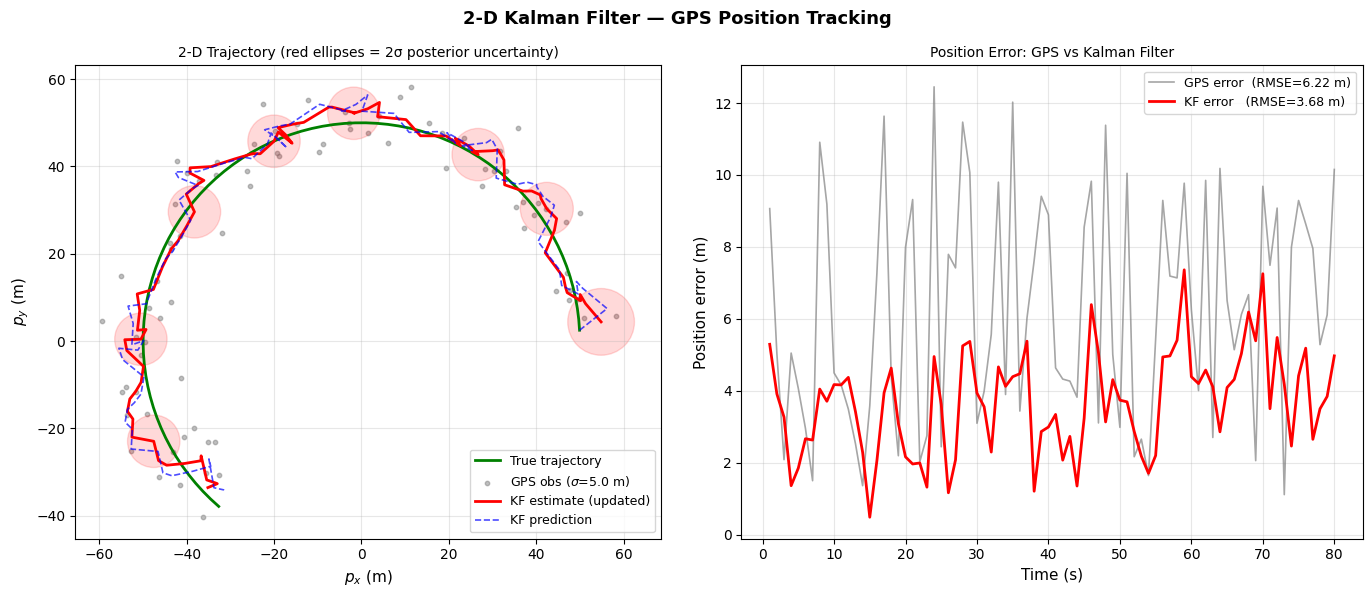

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ═══════════════════════════════════════════════════════════════════════
#  2-D Kalman Filter Implementation
# ═══════════════════════════════════════════════════════════════════════

class KalmanFilter2D:
    """
    Linear Kalman filter for 2-D constant-velocity position tracking.
    
    State:  x = [px, py, vx, vy]^T
    Obs:    y = [px_meas, py_meas]^T
    """

    def __init__(self, dt, sigma_p, sigma_m, m0, P0):
        """
        Parameters
        ----------
        dt      : float  – time step (s)
        sigma_p : float  – std dev of process noise acceleration (m/s²)
        sigma_m : float  – std dev of measurement noise (m)
        m0      : (4,)   – initial state mean
        P0      : (4,4)  – initial state covariance
        """
        dt2 = dt ** 2

        # ── Model matrices ───────────────────────────────────────────
        self.A = np.array([[1, 0, dt, 0],
                           [0, 1,  0, dt],
                           [0, 0,  1,  0],
                           [0, 0,  0,  1]], dtype=float)

        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]], dtype=float)

        G = np.array([[0.5 * dt2,         0],
                      [0,         0.5 * dt2],
                      [dt,                0],
                      [0,                dt]], dtype=float)

        self.Sigma_p = G @ (sigma_p**2 * np.eye(2)) @ G.T   # (4×4) process noise cov
        self.Sigma_m = sigma_m**2 * np.eye(2)                # (2×2) measurement noise cov

        # ── State ────────────────────────────────────────────────────
        self.m = m0.copy()
        self.P = P0.copy()

    # ─────────────────────────────────────────────────────────────────
    def predict(self):
        """Time update (prediction step)."""
        self.m = self.A @ self.m
        self.P = self.A @ self.P @ self.A.T + self.Sigma_p
        return self.m.copy(), self.P.copy()

    # ─────────────────────────────────────────────────────────────────
    def update(self, y_obs):
        """Measurement update step given observation y_obs (2,)."""
        S  = self.H @ self.P @ self.H.T + self.Sigma_m          # innovation cov
        K  = self.P @ self.H.T @ np.linalg.inv(S)               # Kalman gain
        nu = y_obs - self.H @ self.m                             # innovation
        self.m = self.m + K @ nu
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return self.m.copy(), self.P.copy()

    # ─────────────────────────────────────────────────────────────────
    def filter(self, observations):
        """
        Run the full filter over a sequence of observations.
        
        Parameters
        ----------
        observations : (T, 2) array of noisy position measurements
        
        Returns
        -------
        m_pred : (T, 4) – predicted state means
        P_pred : (T, 4, 4) – predicted state covariances
        m_upd  : (T, 4) – updated state means
        P_upd  : (T, 4, 4) – updated state covariances
        """
        T = len(observations)
        m_pred = np.zeros((T, 4));   P_pred = np.zeros((T, 4, 4))
        m_upd  = np.zeros((T, 4));   P_upd  = np.zeros((T, 4, 4))

        for k, y in enumerate(observations):
            mp, Pp = self.predict()
            m_pred[k], P_pred[k] = mp, Pp
            mu, Pu = self.update(y)
            m_upd[k], P_upd[k]   = mu, Pu

        return m_pred, P_pred, m_upd, P_upd


# ═══════════════════════════════════════════════════════════════════════
#  Simulate a GPS tracking scenario
# ═══════════════════════════════════════════════════════════════════════

np.random.seed(7)

# ── Scenario parameters ────────────────────────────────────────────────
dt       = 1.0      # 1-second sampling
T        = 80       # total steps
sigma_p  = 0.5      # process noise std (m/s²)
sigma_m  = 5.0      # GPS measurement noise std (m)

# ── Simulate true trajectory (curved path) ────────────────────────────
t = np.arange(T + 1) * dt
px_true = 50 * np.cos(0.05 * t)
py_true = 50 * np.sin(0.05 * t)
vx_true = np.gradient(px_true, dt)
vy_true = np.gradient(py_true, dt)

# ── Simulate noisy GPS observations ───────────────────────────────────
px_obs = px_true[1:] + sigma_m * np.random.randn(T)
py_obs = py_true[1:] + sigma_m * np.random.randn(T)
observations = np.column_stack([px_obs, py_obs])

# ── Initial conditions ────────────────────────────────────────────────
m0 = np.array([px_true[0], py_true[0], vx_true[0], vy_true[0]])
P0 = np.diag([sigma_m**2, sigma_m**2, 10.0, 10.0])

# ── Run filter ────────────────────────────────────────────────────────
kf = KalmanFilter2D(dt=dt, sigma_p=sigma_p, sigma_m=sigma_m, m0=m0, P0=P0)
m_pred, P_pred, m_upd, P_upd = kf.filter(observations)

# ═══════════════════════════════════════════════════════════════════════
#  Plotting
# ═══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("2-D Kalman Filter — GPS Position Tracking", fontsize=13, fontweight='bold')

# ── Left: trajectory in 2-D space ────────────────────────────────────
ax = axes[0]
ax.plot(px_true[1:], py_true[1:], 'g-',  lw=2.0, label='True trajectory')
ax.scatter(px_obs, py_obs, s=10, c='gray', alpha=0.5, label=f'GPS obs ($\sigma$={sigma_m} m)')
ax.plot(m_upd[:, 0], m_upd[:, 1], 'r-', lw=2.0, label='KF estimate (updated)')
ax.plot(m_pred[:, 0], m_pred[:, 1], 'b--', lw=1.2, alpha=0.7, label='KF prediction')

# Draw 2-sigma uncertainty ellipses at every 10th step
from matplotlib.patches import Ellipse
import scipy.linalg as la

for k in range(0, T, 10):
    cov2 = P_upd[k, :2, :2]
    vals, vecs = la.eigh(cov2)
    order   = vals.argsort()[::-1]
    vals    = vals[order]; vecs = vecs[:, order]
    angle   = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h_e  = 2 * 2 * np.sqrt(vals)
    ell = Ellipse(xy=(m_upd[k, 0], m_upd[k, 1]),
                  width=w, height=h_e, angle=angle,
                  edgecolor='red', facecolor='red', alpha=0.15, lw=1.0)
    ax.add_patch(ell)

ax.set_xlabel('$p_x$ (m)', fontsize=11)
ax.set_ylabel('$p_y$ (m)', fontsize=11)
ax.legend(fontsize=9)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_title('2-D Trajectory (red ellipses = 2σ posterior uncertainty)', fontsize=10)

# ── Right: position error comparison ─────────────────────────────────
ax2 = axes[1]
err_obs = np.sqrt((px_obs - px_true[1:])**2 + (py_obs - py_true[1:])**2)
err_kf  = np.sqrt((m_upd[:, 0] - px_true[1:])**2 + (m_upd[:, 1] - py_true[1:])**2)

time_axis = np.arange(1, T + 1) * dt
ax2.plot(time_axis, err_obs, 'gray', alpha=0.7, lw=1.2, label=f'GPS error  (RMSE={err_obs.mean():.2f} m)')
ax2.plot(time_axis, err_kf,  'r-',   lw=2.0,   label=f'KF error   (RMSE={err_kf.mean():.2f} m)')
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Position error (m)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_title('Position Error: GPS vs Kalman Filter', fontsize=10)

print(f"GPS RMSE : {err_obs.mean():.3f} m")
print(f"KF  RMSE : {err_kf.mean():.3f} m")
print(f"Improvement factor: {err_obs.mean() / err_kf.mean():.2f}x")

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/kalman_2d_tracking.png', dpi=150, bbox_inches='tight')
plt.show()


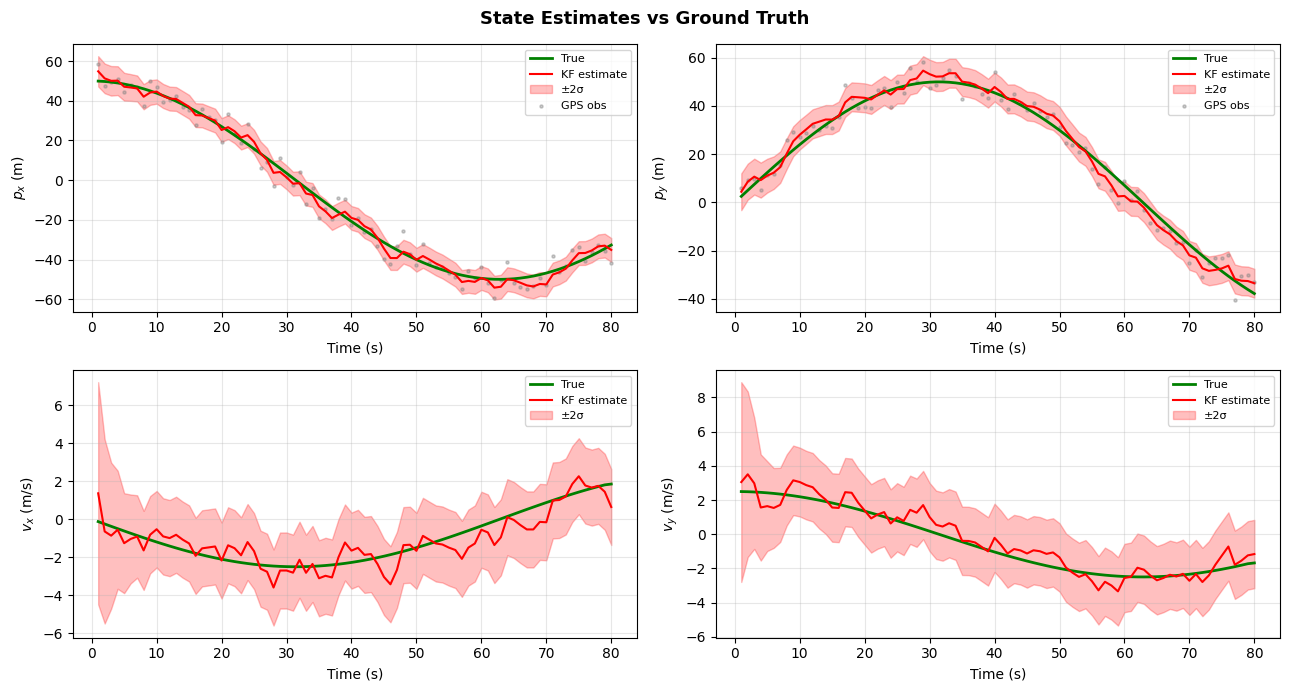

Plots saved.


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  Velocity estimation quality
# ═══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("State Estimates vs Ground Truth", fontsize=13, fontweight='bold')

labels   = ['$p_x$ (m)', '$p_y$ (m)', '$v_x$ (m/s)', '$v_y$ (m/s)']
true_vals = np.column_stack([px_true[1:], py_true[1:], vx_true[1:], vy_true[1:]])
obs_pos   = np.column_stack([px_obs, py_obs, np.full(T, np.nan), np.full(T, np.nan)])

for i, ax in enumerate(axes.flat):
    ax.plot(time_axis, true_vals[:, i], 'g-', lw=2.0, label='True')
    ax.plot(time_axis, m_upd[:, i],     'r-', lw=1.5, label='KF estimate')
    
    # 2-sigma band
    std = np.sqrt(P_upd[:, i, i])
    ax.fill_between(time_axis,
                    m_upd[:, i] - 2 * std,
                    m_upd[:, i] + 2 * std,
                    alpha=0.25, color='red', label='±2σ')
    
    if i < 2:
        ax.scatter(time_axis, obs_pos[:, i], s=5, c='gray', alpha=0.4, label='GPS obs')

    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel(labels[i], fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/kalman_state_estimates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved.")
